# OkCupid Profile Analysis — Data Analyst Case Study

**Author:** Tomer Hakak  ·  **Stack:** Python · pandas · scikit-learn · seaborn

This notebook walks through my full thought process on ~60,000 OkCupid profiles —
from raw CSV to a focused business answer. It is the narrated companion to
[`work.py`](work.py), which automates the same pipeline and generates an
interactive dashboard.

## The business question
> **Who are the most engaged users on the platform, and what distinguishes them?**

Supporting questions: who are the users, how do they behave, can we model their
lifestyle, and — critically — *how do we evaluate a model honestly* on imbalanced data?

> **Note:** The dataset (`okcupid_profiles.csv`, ~131 MB) is not committed to the repo
> (it exceeds GitHub's 100 MB limit). Download it from
> [Kaggle](https://www.kaggle.com/datasets/andrewmvd/okcupid-profiles) and place it
> next to this notebook before running.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", 40)

## 1. Load & inspect

Each row is one user profile; columns are attributes (age, sex, location, lifestyle…).
The 10 free-text `essay` columns aren't useful for quantitative analysis, so they go.

In [2]:
df = pd.read_csv("okcupid_profiles.csv")
print(f"Raw shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head(3)

Raw shape: 59,946 rows x 31 columns


,age,status,sex,orientation,body_type,diet,drinks,drugs,education,ethnicity,height,income,job,last_online,location,offspring,pets,religion,sign,smokes,speaks,essay0,essay1,essay2,essay3,essay4,essay5,essay6,essay7,essay8,essay9
0,22,single,m,straight,a little extra,strictly anything,socially,never,working on college/university,"asian, white",75.0,-1,transportation,2012-06-28-20-30,"south san francisco, california","doesn't have kids, but might want them",likes dogs and likes cats,agnosticism and very serious about it,gemini,sometimes,english,about me: i would love to think that i was so...,currently working as an international agent fo...,making people laugh. ranting about a good salt...,"the way i look. i am a six foot half asian, ha...","books: absurdistan, the republic, of mice and ...",food. water. cell phone. shelter.,duality and humorous things,trying to find someone to hang out with. i am ...,i am new to california and looking for someone...,you want to be swept off your feet! you are ti...
1,35,single,m,straight,average,mostly other,often,sometimes,working on space camp,white,70.0,80000,hospitality / travel,2012-06-29-21-41,"oakland, california","doesn't have kids, but might want them",likes dogs and likes cats,agnosticism but not too serious about it,cancer,no,"english (fluently), spanish (poorly), french (...",i am a chef: this is what that means. 1. i am ...,dedicating everyday to being an unbelievable b...,being silly. having ridiculous amonts of fun w...,NaN,i am die hard christopher moore fan. i don't r...,delicious porkness in all of its glories. my b...,NaN,NaN,i am very open and will share just about anyth...,NaN
2,38,available,m,straight,thin,anything,socially,NaN,graduated from masters program,NaN,68.0,-1,NaN,2012-06-27-09-10,"san francisco, california",NaN,has cats,NaN,pisces but it doesn&rsquo;t matter,no,"english, french, c++","i'm not ashamed of much, but writing public te...","i make nerdy software for musicians, artists, ...",improvising in different contexts. alternating...,my large jaw and large glasses are the physica...,okay this is where the cultural matrix gets so...,movement conversation creation contemplation t...,NaN,viewing. listening. dancing. talking. drinking...,"when i was five years old, i was known as ""the...","you are bright, open, intense, silly, ironic, ..."


## 2. Cleaning

Two steps that matter: drop the essays, and convert empty strings to real `NaN` so
that missing-value logic and `dropna` behave correctly downstream.

In [3]:
essay_cols = [f"essay{i}" for i in range(10)]
df = df.drop(columns=essay_cols, errors="ignore")
df = df.replace(r"^\s*$", np.nan, regex=True)
print(f"After cleaning: {df.shape[0]:,} rows x {df.shape[1]} columns")

After cleaning: 59,946 rows x 21 columns


## 3. Data quality

Before trusting any column, I check how complete it is. Anything above ~30% missing
is a candidate to drop or treat carefully — e.g. `income` is undisclosed (`-1`) by
most users and adds noise, not signal.

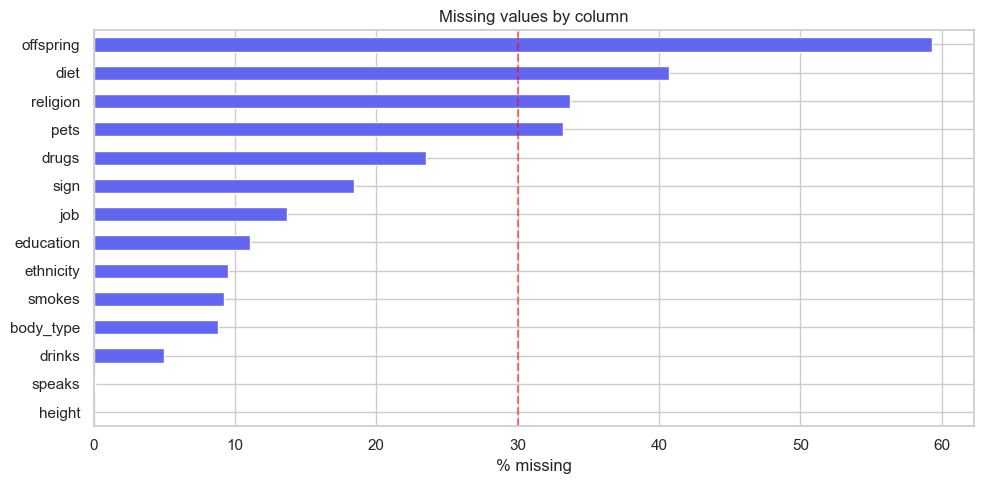

In [4]:
missing = (df.isna().mean() * 100).sort_values()
missing = missing[missing > 0]
ax = missing.plot.barh(color="#6366f1", edgecolor="white")
ax.axvline(30, color="red", ls="--", alpha=0.5)
ax.set_xlabel("% missing")
ax.set_title("Missing values by column")
plt.tight_layout(); plt.show()

## 4. Who are the users? (demographics)

A young, single, male-skewed and hyper-local (San Francisco) audience.

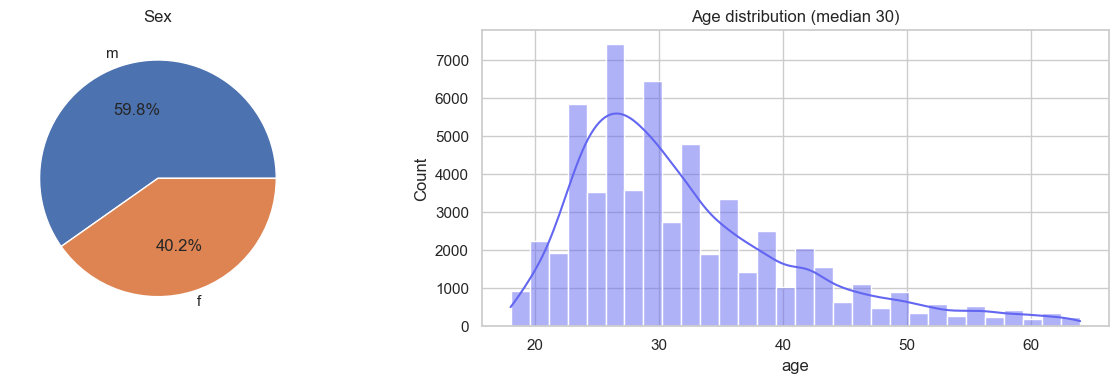

Top 5 locations:
location
san francisco, california    31064
oakland, california           7214
berkeley, california          4212
san mateo, california         1331
palo alto, california         1064
Name: count, dtype: int64


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
df["sex"].value_counts().plot.pie(autopct="%1.1f%%", ax=axes[0], ylabel="",
                                  colors=["#4C72B0", "#DD8452"])
axes[0].set_title("Sex")

age = df[(df["age"] >= 18) & (df["age"] < 65)]
sns.histplot(age["age"], bins=30, kde=True, ax=axes[1], color="#6366f1")
axes[1].set_title(f"Age distribution (median {age['age'].median():.0f})")
plt.tight_layout(); plt.show()

print("Top 5 locations:")
print(df["location"].value_counts().head(5))

## 5. The business question — user engagement

I define **engagement** from `last_online` recency, measured against the most recent
timestamp in the data (this is a 2012 snapshot, so I anchor to its max date). Then I
ask: **does a more complete profile mean a more engaged user?** If yes, "nudge profile
completion" becomes a concrete, low-cost growth lever.

In [6]:
# Profile completeness = share of non-empty fields per user
profile_fields = list(df.columns)
df["completeness"] = df[profile_fields].notna().mean(axis=1) * 100

# Recency
df["last_online_dt"] = pd.to_datetime(df["last_online"], format="%Y-%m-%d-%H-%M", errors="coerce")
ref_date = df["last_online_dt"].max()
df["days_since_online"] = (ref_date - df["last_online_dt"]).dt.days

eng = df.dropna(subset=["days_since_online"]).copy()
active_pct = (eng["days_since_online"] <= 30).mean() * 100
print(f"Reference (latest) date in data: {ref_date}")
print(f"Active in last 30 days: {active_pct:.1f}%")

Reference (latest) date in data: 2012-07-01 08:57:00
Active in last 30 days: 74.6%


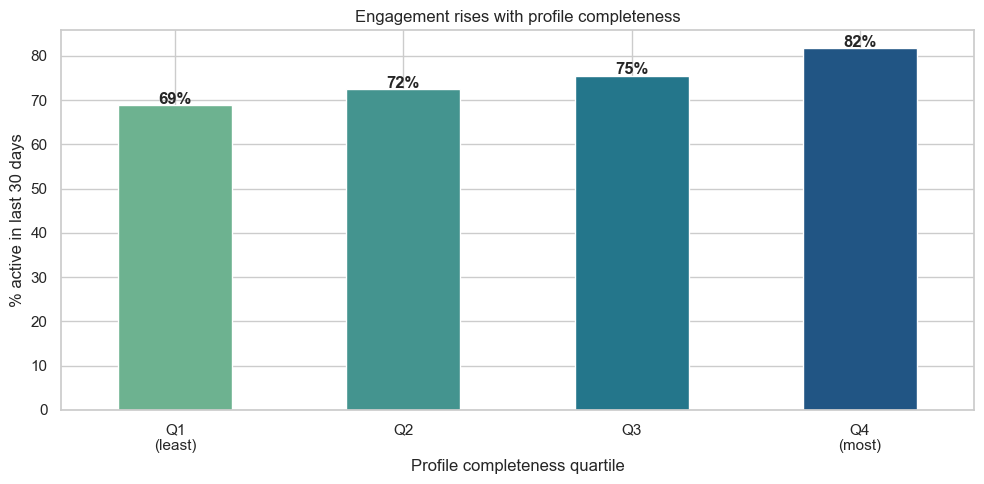

Active-rate lift, most vs least complete: +12.9 pts


In [7]:
eng["active30"] = eng["days_since_online"] <= 30
# Rank-based quartiles avoid duplicate-edge errors (completeness is coarsely valued)
eng["completeness_q"] = pd.qcut(eng["completeness"].rank(method="first"), 4,
                                labels=["Q1\n(least)", "Q2", "Q3", "Q4\n(most)"])
rate = eng.groupby("completeness_q", observed=True)["active30"].mean() * 100

ax = rate.plot.bar(color=sns.color_palette("crest", 4), edgecolor="white", rot=0)
for i, v in enumerate(rate):
    ax.text(i, v + 0.4, f"{v:.0f}%", ha="center", fontweight="bold")
ax.set_ylabel("% active in last 30 days")
ax.set_xlabel("Profile completeness quartile")
ax.set_title("Engagement rises with profile completeness")
plt.tight_layout(); plt.show()

print(f"Active-rate lift, most vs least complete: +{rate.iloc[-1] - rate.iloc[0]:.1f} pts")

**Answer:** the most-complete profiles are markedly more likely to be active than
the least-complete ones. That gap is the single most actionable result here:
encouraging profile completion (progress bars, onboarding prompts) should directly
raise engagement.

## 6. Segmentation — K-Means on age × height

Using the Elbow Method to pick `k`, then segmenting users. Features are standardized
first so neither dimension dominates the distance metric.

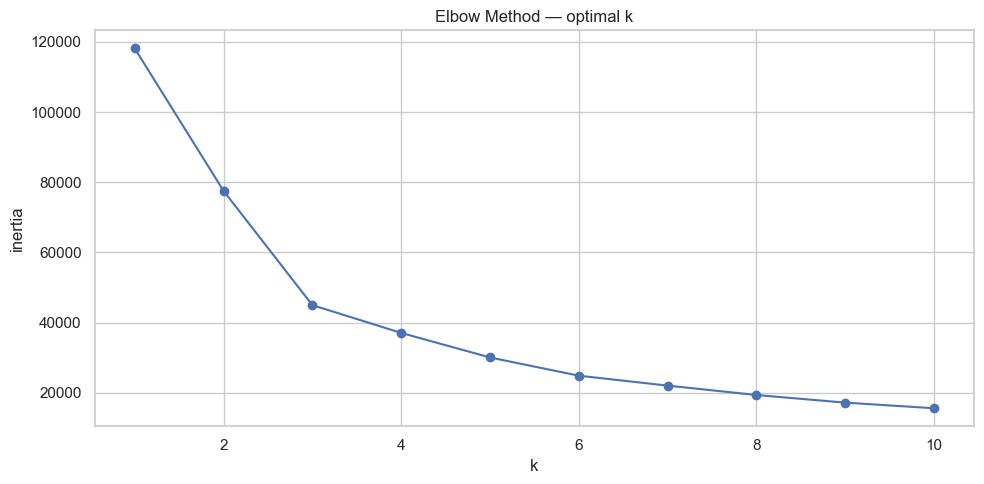

In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

cl = df[["age", "height"]].dropna()
cl = cl[(cl["age"] >= 18) & (cl["age"] < 65) & (cl["height"] >= 60) & (cl["height"] <= 78)]
X = StandardScaler().fit_transform(cl)

inertia = [KMeans(n_clusters=k, random_state=42, n_init=10).fit(X).inertia_ for k in range(1, 11)]
plt.plot(range(1, 11), inertia, marker="o")
plt.title("Elbow Method — optimal k"); plt.xlabel("k"); plt.ylabel("inertia")
plt.tight_layout(); plt.show()

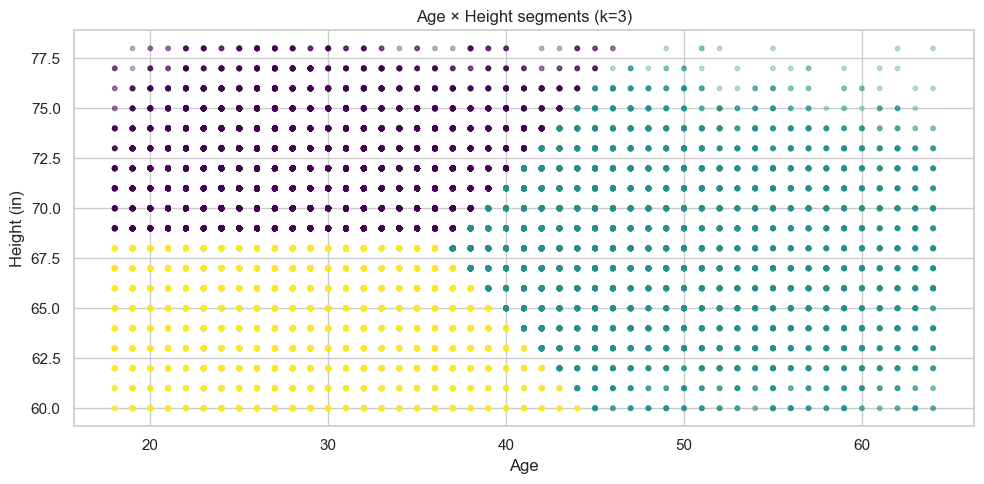

In [9]:
km = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = km.fit_predict(X)
plt.scatter(cl["age"], cl["height"], c=labels, cmap="viridis", alpha=0.3, s=10)
plt.title("Age × Height segments (k=3)"); plt.xlabel("Age"); plt.ylabel("Height (in)")
plt.tight_layout(); plt.show()

## 7. Modeling done honestly — the most important section

I'll predict the 6-class `drinks` attribute. This is **imbalanced**: ~73% of users
answer *"socially"*. A model that always guesses "socially" scores **73% accuracy
while learning nothing** — so accuracy alone is a trap. I compare a naive baseline
against a class-balanced Random Forest, and report **macro-F1 / balanced accuracy**,
which actually reward distinguishing the minority classes.

In [10]:
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                             f1_score, classification_report)

cols = ["age", "sex", "education", "body_type", "smokes", "drinks"]
m = df[cols].dropna().copy()
for c in m.select_dtypes("object"):
    m[c] = LabelEncoder().fit_transform(m[c].astype(str))

Xx, yy = m.drop(columns="drinks"), m["drinks"]
Xtr, Xte, ytr, yte = train_test_split(Xx, yy, test_size=0.3, random_state=42, stratify=yy)

base = DummyClassifier(strategy="most_frequent").fit(Xtr, ytr)
bp = base.predict(Xte)
rf = RandomForestClassifier(n_estimators=200, max_depth=12, class_weight="balanced",
                            random_state=42, n_jobs=-1).fit(Xtr, ytr)
pp = rf.predict(Xte)

print(f"Baseline   : acc {accuracy_score(yte, bp):.3f} | "
      f"macro-F1 {f1_score(yte, bp, average='macro', zero_division=0):.3f}")
print(f"RF balanced: acc {accuracy_score(yte, pp):.3f} | "
      f"bal-acc {balanced_accuracy_score(yte, pp):.3f} | "
      f"macro-F1 {f1_score(yte, pp, average='macro', zero_division=0):.3f}")
print()
print(classification_report(yte, pp, zero_division=0))

Baseline   : acc 0.733 | macro-F1 0.141
RF balanced: acc 0.435 | bal-acc 0.222 | macro-F1 0.195

              precision    recall  f1-score   support

           0       0.01      0.04      0.01        74
           1       0.11      0.23      0.15       784
           2       0.17      0.28      0.21      1177
           3       0.14      0.23      0.17      1465
           4       0.76      0.51      0.61      9879
           5       0.01      0.05      0.02       107

    accuracy                           0.43     13486
   macro avg       0.20      0.22      0.20     13486
weighted avg       0.59      0.43      0.49     13486



Notice the twist: the balanced model's **accuracy is *lower* than the baseline's**,
but its **macro-F1 and per-class recall are higher** — it actually distinguishes
categories instead of collapsing onto "socially". The honest conclusion: **profile
attributes carry only weak signal for predicting drinking habits.** Reporting "73%
accuracy" would have hidden that completely.

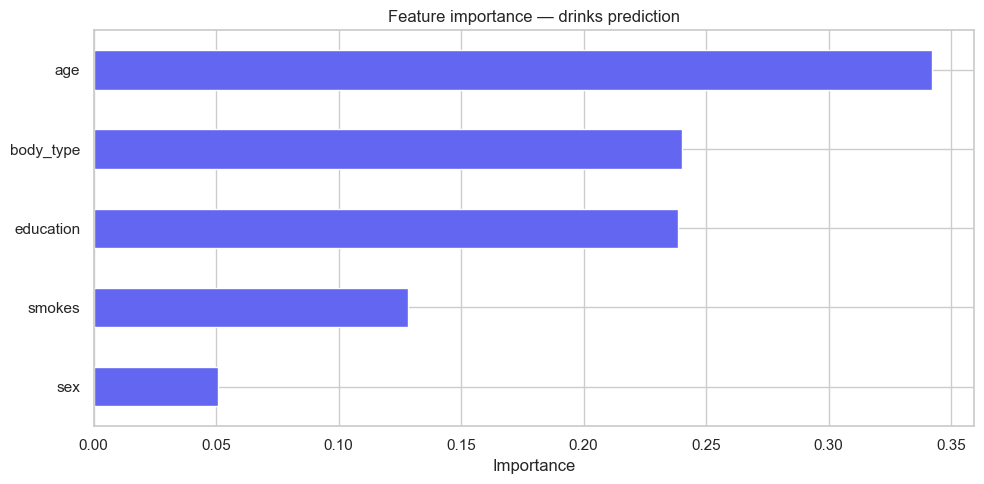

In [11]:
imp = pd.Series(rf.feature_importances_, index=Xx.columns).sort_values()
imp.plot.barh(color="#6366f1", edgecolor="white")
plt.title("Feature importance — drinks prediction")
plt.xlabel("Importance"); plt.tight_layout(); plt.show()

## 8. Conclusions & recommendations

1. **Profile completeness is the engagement lever** — the most-complete profiles are
   meaningfully more active. Nudge completion (progress bars, onboarding prompts).
2. **The audience is hyper-local** — over half of users are in San Francisco; lean
   into local features.
3. **Fix data-collection gaps** — `offspring`, `diet`, `religion` are largely empty;
   `income` is mostly undisclosed and should be excluded from modeling.
4. **Don't over-trust the lifestyle model** — profile attributes alone aren't enough
   to infer drinking habits; richer behavioral data would be needed before shipping it.

**Methodological takeaway:** always benchmark against a baseline and pick metrics that
fit the data. On imbalanced targets, accuracy flatters; macro-F1 tells the truth.